In [63]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from scipy import stats
from scipy.special import erfcinv
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initialization

In [64]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [65]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[:30]
depth = depth - np.nanmin(depth)
conc = conc[:, :30]

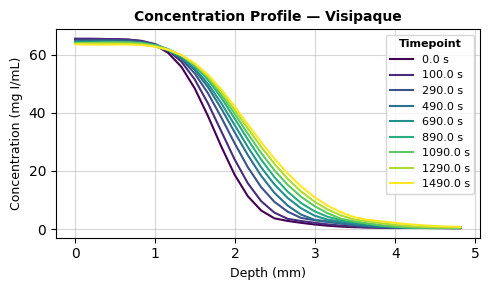

In [66]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

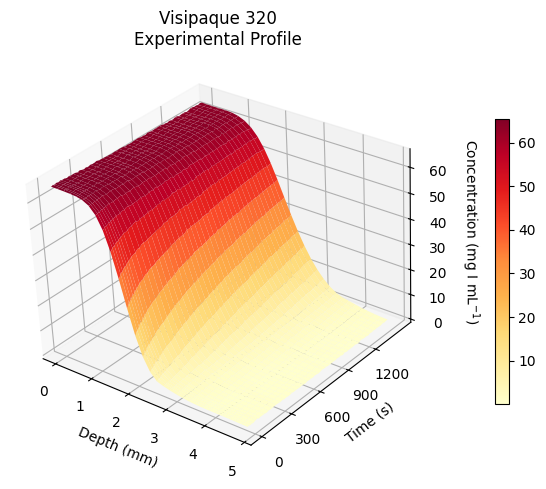

In [67]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# ICD Method

In [68]:
def icd_method(c_null, conc, time):
    try:
        t_front = np.sqrt(time)
        x_front = []
        cs_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        n = len(x_front)

        slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - marg_of_err
        slope_upper = slope + marg_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2"            : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [69]:
c_null_list = [10, 15, 20, 30]
icd_results = [icd_method(c_null, conc, time) for c_null in c_null_list]
for r in icd_results:
    print(f"{r["c_null"]} mg I/mL: {r["d"]:.2e} [{r["ci_d"][0]:.2e}, {r["ci_d"][1]:.2e}] mm2/s (r2 = {r["r2"]:.3f})")

10 mg I/mL: 1.41e-04 [1.34e-04, 1.47e-04] mm2/s (r2 = 0.990)
15 mg I/mL: 1.51e-04 [1.45e-04, 1.57e-04] mm2/s (r2 = 0.991)
20 mg I/mL: 1.63e-04 [1.57e-04, 1.69e-04] mm2/s (r2 = 0.993)
30 mg I/mL: 1.99e-04 [1.93e-04, 2.04e-04] mm2/s (r2 = 0.996)


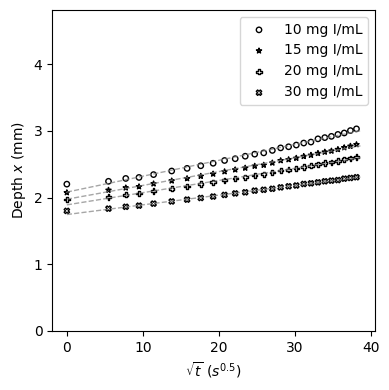

In [70]:
fig, ax = plt.subplots(figsize = (4, 4))
cats = [str(c) + " mg I /mL" for c in c_null_list]
markers = ["o", "*", "P", "X"]

for i, r in enumerate(icd_results):
        t_front = r["t_0.5"]
        x_front = r["iso_front"]
        c_null = r["c_null"]
        intercept = r["intercept"]
        slope = r["slope"]

        ax.scatter(t_front[::3], x_front[::3], 
                marker = markers[i], 
                edgecolors = "black", 
                facecolors = "none", 
                s  = 15,
                label = f"{c_null} mg I/mL")
        ax.set_xlabel(f"$\\sqrt{{t}}$ ($s^{{0.5}}$)")
        ax.set_ylabel(f"Depth $x$ (mm)")

        # plot regression line
        x_reg = np.linspace(0, np.nanmax(t_front), len(t_front))
        y_reg = slope * x_reg + intercept
        ax.plot(x_reg, y_reg, 
                linestyle = "--",
                c = "grey",
                alpha = 0.7,
                linewidth = 1)
ax.set_ylim(0, np.nanmax(depth))
plt.legend()  
plt.tight_layout()
plt.show()

# No Manual Boundary

In [71]:
# No boundary, so fitting with x0
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs.append(cfg)

In [72]:
results_x0 = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results_x0.append(result)
        bar()

Fitting configs |                                        | ▁▃▅ 0/2 [0%] in 0s (~

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.2s (1


# With Manual Boundary

In [73]:
dat = import_dat(boundary = True)

conc_b, depth_b, time_b = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth_b = depth_b.flatten()
time_b = time_b.flatten()

depth_b = depth_b[:30]
conc_b = conc_b[:, :30]
time_b = time_b

In [74]:
# No boundary, so fitting with x0
configs_b = []
cs_exp = np.nanmean(conc_b[:, 0])
d_mode = "global"

for fit_x0 in [False]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs_b.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs_b.append(cfg)

In [75]:
results_semi = []
with alive_bar(len(configs_b), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_b:
        result = fitting.fit_diffusion(conc_b, depth_b, time_b, cfg)
        results_semi.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [76]:
def sim_residual(d, cs, conc, time, depth, x0 = 0):
    semi_inf = models.semi_infinite
    conc_sim = np.empty_like(conc)

    for i, ti in enumerate(time):
        if ti == 0:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, 0.001)
        else:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, ti)

    n = conc.size
    p = 1

    residuals = (conc - conc_sim) / conc * 100
    return residuals

In [77]:
results_combined = results_x0 + results_semi
depth_combined = [depth] + [depth] + [depth_b] + [depth_b]
time_combined = [time] + [time] + [time_b] + [time_b]
conc_combined = [conc] + [conc] + [conc_b] + [conc_b]
titles_combined = [f"Semi-infinite with $x_0$", 
                   f"Semi-infinite with $x_0$ (Fixed C$_s$)",
                   f"Manually Selected Boundary",
                   f"Manually Selected Boundary (Fixed C$_s$)"
                   ]
residuals = []

for r, conc, depth, time in zip(results_combined, conc_combined, depth_combined, time_combined):
    d = r.d_global
    cs = cs_exp
    x0 = 0 if r.x0_global is None else r.x0_global

    res = sim_residual(d, cs, conc, time, depth, x0)
    residuals.append(res)


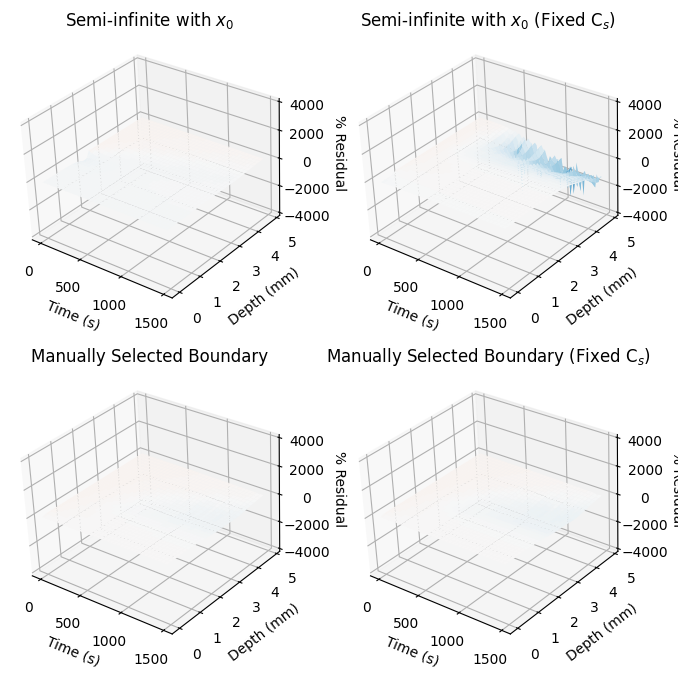

In [78]:
import matplotlib.colors as colors
fig, ax = plt.subplots(2, 2, subplot_kw = {"projection": "3d"}, figsize = (8, 8))

ax = ax.flatten()
max_val = np.nanmax(np.concatenate(residuals))
min_val = np.nanmin(np.concatenate(residuals))
vmin = min_val if abs(min_val) > max_val else -max_val
vmax = max_val if abs(min_val) < max_val else abs(min_val)
norm = colors.TwoSlopeNorm(vcenter = 0.0, vmin = vmin, vmax = vmax)

for i, res in enumerate(residuals):
    depth_mesh, time_mesh = np.meshgrid(depth_combined[i], time_combined[i])
    surf = ax[i].plot_surface(time_mesh, depth_mesh, res,
                              linewidth = 0, cmap = "RdBu_r",
                              norm = norm)
    ax[i].view_init(elev = 30, azim = -50, roll = 3)
    ax[i].set_ylabel("Depth (mm)")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_zlabel("% Residual")
    ax[i].set_zlim(vmin, vmax)
    ax[i].set_title(titles_combined[i])

plt.show()

In [79]:
[print(f"{title}: " f"{r.d_global:.2e}") for title, r in zip(titles_combined, results_combined)]

Semi-infinite with $x_0$: 2.88e-04
Semi-infinite with $x_0$ (Fixed C$_s$): 2.98e-03
Manually Selected Boundary: 1.02e-03
Manually Selected Boundary (Fixed C$_s$): 1.16e-03


[None, None, None, None]

In [103]:
results_combined[2].lb_all

array([9.88385966e-04, 6.59990473e+01])

In [114]:
# Exporting data to dfs
rows = []
for r in results_combined:
    cfg = r.config

    d_summary = r.d_global
    cs_summary = r.cs_global
    x0_summary = r.x0_global if cfg.fit_x0 else np.nan

    if cfg.fit_x0:
        d_ci = (r.lb_all[1], r.ub_all[1])
        x0_ci = (r.lb_all[0], r.ub_all[0])
        cs_ci = (r.lb_all[2], r.ub_all[2]) if cfg.cs_mode == "global" else (np.nan, np.nan)
    else:
        d_ci = (r.lb_all[0], r.ub_all[0])
        cs_ci = (r.lb_all[1], r.ub_all[1]) if cfg.cs_mode == "global" else (np.nan, np.nan)
        x0_ci = (np.nan, np.nan)

    rows.append({
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "fit_x0": cfg.fit_x0,
        "d": d_summary,
        "cs": cs_summary,
        "x0": x0_summary,
        "r2": r.r2_global,
        "rse": r.rse_global,
        "d_ci": d_ci,
        "cs_ci": cs_ci,
        "x0_ci": x0_ci,
        "aic": r.aic
    })

In [115]:
summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["aic"] - summary_df["aic"].min()
summary_df

,d_mode,cs_mode,fit_x0,d,cs,x0,r2,rse,d_ci,cs_ci,x0_ci,aic,delta_aic
0,global,global,True,0.000288,32.888158,2.008024,0.977760,4.054208,"(0.00027519962342866075, 0.0003001174445283662)","(32.713660836970774, 33.06265480531417)","(2.0002066160418552, 2.0158422993937206)",6721.823877,0.000000
1,global,fixed,True,0.002982,64.449782,0.628168,0.797592,12.228271,"(0.00282760787051485, 0.003136131649358218)","(nan, nan)","(0.6053201873041362, 0.6510159549355358)",12020.001692,5298.177815
2,global,global,False,0.001021,66.776276,NaN,0.923139,5.480010,"(0.000988385965625519, 0.001054548100675323)","(65.99904725726807, 67.55350377259072)","(nan, nan)",8167.312510,1445.488634
3,global,fixed,False,0.001159,61.624955,NaN,0.917527,5.675357,"(0.0011260075232137489, 0.0011918995284605281)","(nan, nan)","(nan, nan)",8334.440108,1612.616232


In [117]:
results_combined[1].n_obs_total

2400

# Shifting timepoints

In [80]:
valid_indices = [np.arange(len(time))[i:] for i in range(0, len(time) - 10, 5)]

In [81]:
# No boundary, so fitting with x0
configs_shift = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True, False]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        for idx in valid_indices:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (-np.inf, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp,
                    fit_indices = idx
                )
                configs_shift.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (-np.inf, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    fit_indices = idx
                )
                configs_shift.append(cfg)

In [82]:
results_shift = {}
with alive_bar(len(configs_shift), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_shift:
        if cfg.fit_x0:
            result = fitting.fit_diffusion(conc, depth, time, cfg)
        else:
            result = fitting.fit_diffusion(conc_b, depth_b, time_b, cfg)
        cs_mode = cfg.cs_mode
        x0_mode = "autox0" if cfg.fit_x0 else "manualx0"
        key = cs_mode + "_" + x0_mode

        if key not in results_shift.keys():
            results_shift[key] = []

        results_shift[key].append(result)
        
        bar()

Fitting configs |████████████████████████████████████████| 60/60 [100%] in 0.9s 


In [83]:
for key in results_shift.keys():
    print("----------")
    print(f"{key}")
    print("----------")
    for r in results_shift[key]:
            print(f"Starting at {r.valid_times[0]} s: D = {r.d_global:.2e} mm2/s, Cs = {r.cs_global:.2f} (r2 = {r.r2_global:.3f})")

----------
global_autox0
----------
Starting at 10.0 s: D = 4.77e-04 mm2/s, Cs = 37.99 (r2 = 0.962)
Starting at 50.0 s: D = 5.41e-04 mm2/s, Cs = 41.25 (r2 = 0.972)
Starting at 100.0 s: D = 5.43e-04 mm2/s, Cs = 43.23 (r2 = 0.981)
Starting at 190.0 s: D = 4.89e-04 mm2/s, Cs = 42.62 (r2 = 0.987)
Starting at 290.0 s: D = 4.10e-04 mm2/s, Cs = 40.23 (r2 = 0.990)
Starting at 390.0 s: D = 3.48e-04 mm2/s, Cs = 38.22 (r2 = 0.992)
Starting at 490.0 s: D = 3.10e-04 mm2/s, Cs = 37.05 (r2 = 0.994)
Starting at 590.0 s: D = 2.85e-04 mm2/s, Cs = 36.33 (r2 = 0.995)
Starting at 690.0 s: D = 2.67e-04 mm2/s, Cs = 35.87 (r2 = 0.996)
Starting at 790.0 s: D = 2.54e-04 mm2/s, Cs = 35.55 (r2 = 0.997)
Starting at 890.0 s: D = 2.44e-04 mm2/s, Cs = 35.32 (r2 = 0.997)
Starting at 990.0 s: D = 2.37e-04 mm2/s, Cs = 35.19 (r2 = 0.998)
Starting at 1090.0 s: D = 2.31e-04 mm2/s, Cs = 35.07 (r2 = 0.998)
Starting at 1190.0 s: D = 2.27e-04 mm2/s, Cs = 35.08 (r2 = 0.998)
Starting at 1290.0 s: D = 2.24e-04 mm2/s, Cs = 35.09 (